In [ ]:
import pandas as pd
import numpy as np # Import numpy for numerical operations

## Notebook Overview

This notebook performs comprehensive data cleaning, preprocessing, and exploratory data analysis (EDA) on a dataset of Reddit comments. The goal is to prepare the text data for potential sentiment analysis or other NLP tasks.

### 1. Data Loading and Initial Inspection

This section loads the dataset from a CSV file into a pandas DataFrame and performs initial checks to understand its structure and content.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head() # Display the first few rows of the DataFrame

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


### 2. Handling Missing Values

Identifies and removes rows where the `clean_comment` column contains missing (NaN) values, as these comments cannot be analyzed.

In [ ]:
df.info() # Display concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [ ]:
df['category'].value_counts() # Count the occurrences of each unique value in the 'category' column

,count
category,
1,15830
0,13142
-1,8277


# handel missing value

In [ ]:
df.isnull().sum() # Calculate the sum of null values for each column

,0
clean_comment,100
category,0


In [ ]:
null_df = df[df['clean_comment'].isna()] # Create a DataFrame containing rows where 'clean_comment' is null

In [ ]:
null_df['category'].value_counts() # Count the occurrences of each category in the null_df

,count
category,
0,100


In [ ]:
df = df.dropna() # Remove rows with any null values from the DataFrame

### 3. Handling Duplicate Values

Detects and removes duplicate rows from the DataFrame, ensuring that each comment is unique and does not skew the analysis.

In [ ]:
df.isnull().sum() # Verify that there are no remaining null values

,0
clean_comment,0
category,0


# handel duplicate value

In [ ]:
df.duplicated().sum() # Count the number of duplicated rows in the DataFrame

np.int64(350)

In [ ]:
df[df.duplicated()] # Display the duplicated rows in the DataFrame

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [ ]:
df.drop_duplicates(keep='first', inplace=True) # Remove duplicate rows, keeping the first occurrence

### 4. Handling Empty Rows

Identifies and removes rows where the `clean_comment` column contains only whitespace or empty strings after stripping.

In [ ]:
df.duplicated().sum() # Verify that there are no remaining duplicate rows

np.int64(0)

In [ ]:
df.shape # Display the dimensions (rows, columns) of the DataFrame

(36799, 2)

# removed empty rows

In [ ]:
# empty row

df[df['clean_comment'].str.strip() == ""].shape # Find and display the shape of rows where 'clean_comment' is an empty string after stripping whitespace

(6, 2)

In [ ]:
# removed empty row
df = df[~(df['clean_comment'].str.strip() == "")] # Remove rows where 'clean_comment' is an empty string after stripping whitespace

### 5. Text Normalization

Standardizes the text data by converting all comments to lowercase and removing leading/trailing whitespaces.

In [ ]:
df.shape # Display the updated dimensions of the DataFrame

(36793, 2)

# convert to lowe case

In [ ]:
df['clean_comment'] = df['clean_comment'].str.lower() # Convert all text in 'clean_comment' to lowercase

In [ ]:
df.head() # Display the first few rows of the DataFrame with lowercase comments

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


# removed white space start and end

In [ ]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))] # Identify comments that start or end with a space

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [ ]:
df['clean_comment'] = df['clean_comment'].str.strip() # Remove leading and trailing whitespace from 'clean_comment'

### 6. Character/URL/Newline Handling

Checks for and removes specific character types that might interfere with text analysis, such as URLs, newline characters, and non-English characters.

In [ ]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))] # Verify that no comments start or end with a space

,clean_comment,category


In [ ]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head() # Check for comments containing URLs

,clean_comment,category


In [ ]:
# Identify comments containing new line characters
comments_with_newline = df[df['clean_comment'].str.contains('\n')]

# Display the comments containing new line characters
comments_with_newline.head() # Check for comments containing newline characters

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [ ]:
# Remove new line characters from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

# Verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining # Remove newline characters and verify

,clean_comment,category


### 7. Sentiment Category Distribution

Visualizes the distribution of sentiment categories (`-1`, `0`, `1`) in the dataset using bar and pie charts to understand the class balance.

In [ ]:
df.head() # Display the first few rows after newline removal

,clean_comment,category
0,family mormon have never tried explain them th...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


<Axes: xlabel='category', ylabel='count'>

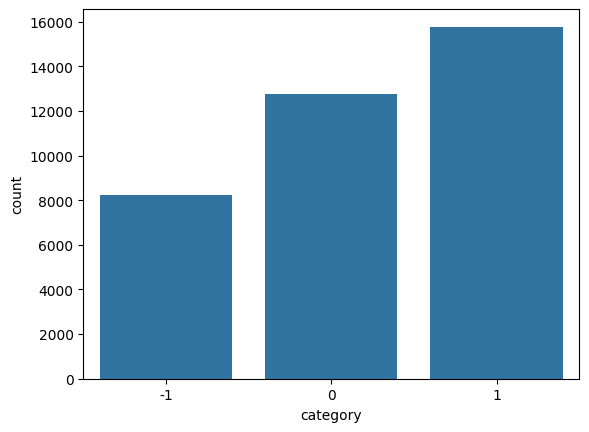

In [ ]:
import seaborn as sns # Import seaborn for plotting
sns.countplot(x='category', data=df) # Create a bar plot of the 'category' distribution

<Axes: ylabel='count'>

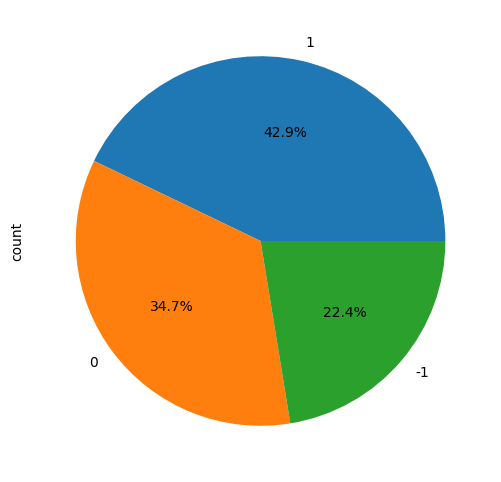

In [ ]:
df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6)) # Create a pie chart of the 'category' distribution

<Axes: xlabel='category'>

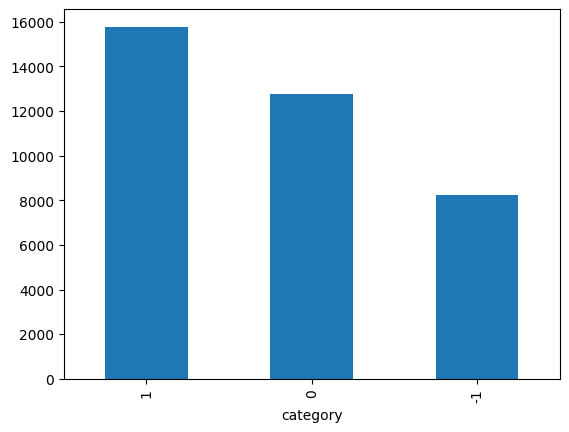

In [ ]:
df['category'].value_counts().plot(kind='bar') # Create a bar plot of the 'category' distribution

In [ ]:
from ast import Mult # This import seems unused and can be removed if not needed elsewhere.
df['category'].value_counts(normalize=True).mul(100).round(2) # Calculate and display the percentage of each category

,proportion
category,
1,42.86
0,34.71
-1,22.42


### 8. Word Count Analysis

Calculates the number of words in each comment and provides descriptive statistics and distribution plots, including comparison across sentiment categories.

In [ ]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split())) # Create a new column 'word_count' with the number of words in each comment

In [ ]:
df.head() # Display the first few rows including the new 'word_count' column

,clean_comment,category,word_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112


In [ ]:
df['word_count'].describe() # Display descriptive statistics for the 'word_count' column

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


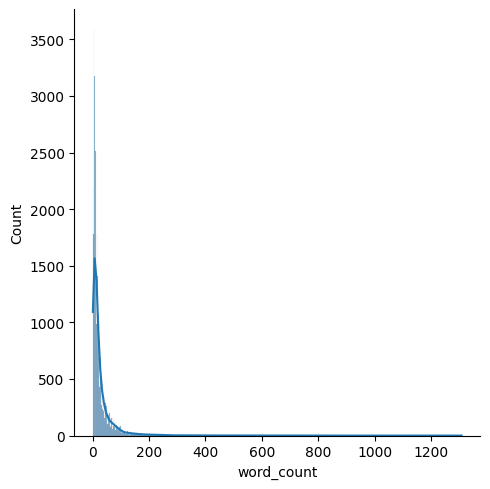

In [ ]:
import seaborn as sns # Import seaborn for plotting
sns.displot(df['word_count'],kde = True) # Create a distribution plot of 'word_count' with a kernel density estimate

### 9. Stop Word Analysis

Downloads necessary NLTK data, identifies, counts, and visualizes the most common English stopwords. It also removes most stopwords, but keeps some that might be relevant for sentiment (e.g., 'not').

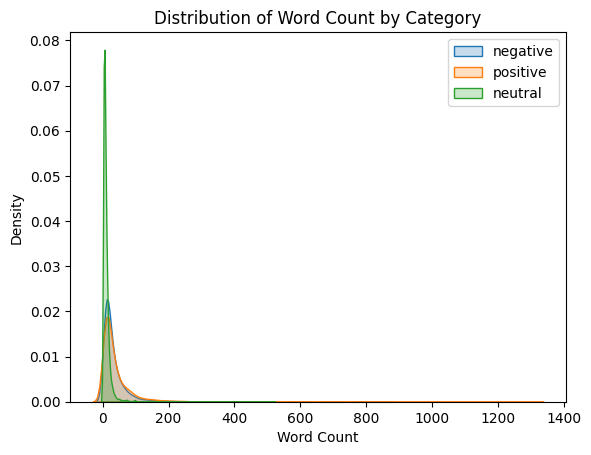

In [ ]:
import  matplotlib.pyplot as plt # Import matplotlib for plotting

sns.kdeplot(df[df['category']==-1]['word_count'], label='negative', fill=True)
sns.kdeplot(df[df['category']==1]['word_count'], label='positive', fill=True)
sns.kdeplot(df[df['category']==0]['word_count'], label='neutral', fill=True)

plt.title('Distribution of Word Count by Category') # Set the title of the plot
plt.xlabel('Word Count') # Set the x-axis label
plt.ylabel('Density') # Set the y-axis label
plt.legend() # Display the legend
plt.show() # Show the plot

<Axes: ylabel='word_count'>

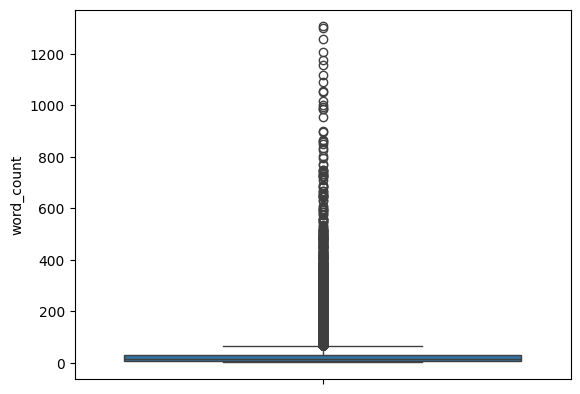

In [ ]:
sns.boxplot(df['word_count']) # Create a box plot of 'word_count' to visualize its distribution and outliers

<Axes: xlabel='category', ylabel='word_count'>

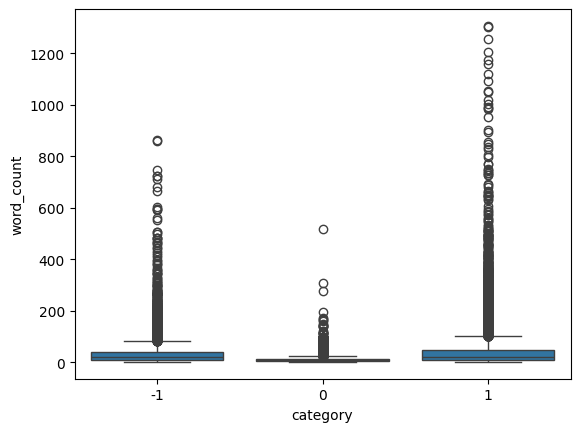

In [ ]:
sns.boxplot(x='category', y='word_count', data=df) # Create box plots of 'word_count' grouped by 'category'

In [ ]:
pip install nltk # Install the Natural Language Toolkit (NLTK) library

In [ ]:
import nltk # Import NLTK
from nltk.corpus import stopwords # Import stopwords from NLTK
from nltk.tokenize import word_tokenize # Import word_tokenize for tokenizing text

nltk.download('punkt') # Download the 'punkt' tokenizer models
nltk.download('punkt_tab') # Download the 'punkt_tab' tokenizer models
nltk.download('stopwords') # Download the list of stopwords

stop_words = set(stopwords.words('english')) # Create a set of English stopwords for efficient lookup

df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in word_tokenize(x) if word.lower() in stop_words])) # Create a new column 'num_stop_words' counting stopwords in each comment

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df.head() # Display the first few rows including the new 'num_stop_words' column

,clean_comment,category,word_count,num_stop_words
0,family mormon have never tried explain them th...,1,39,13
1,buddhism has very much lot compatible with chr...,1,196,59
2,seriously don say thing first all they won get...,-1,86,40
3,what you have learned yours and only yours wha...,0,29,15
4,for your own benefit you may want read living ...,1,112,45


In [ ]:
df['num_stop_words'].describe() # Display descriptive statistics for the 'num_stop_words' column

,num_stop_words
count,36793.000000
mean,9.889381
std,19.493637
min,0.000000
25%,1.000000
50%,4.000000
75%,10.000000
max,463.000000


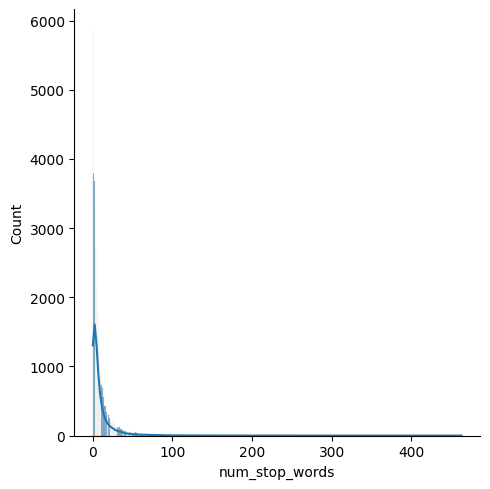

In [ ]:
sns.displot(df['num_stop_words'],kde=True) # Create a distribution plot of 'num_stop_words' with a kernel density estimate

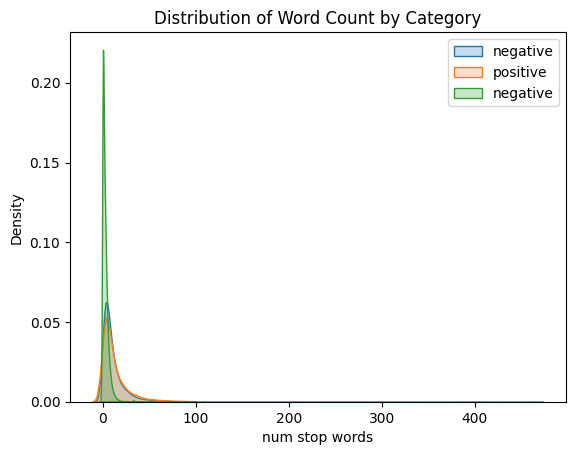

In [ ]:
sns.kdeplot(df[df['category']==-1]['num_stop_words'], label='negative', fill=True)
sns.kdeplot(df[df['category']==1]['num_stop_words'],label = 'positive',fill=True)
sns.kdeplot(df[df['category']==0]['num_stop_words'],label = 'negative',fill=True)

plt.title('Distribution of Word Count by Category') # Set the title of the plot
plt.xlabel('num stop words') # Set the x-axis label
plt.ylabel('Density') # Set the y-axis label
plt.legend() # Display the legend
plt.show() # Show the plot

In [ ]:
from collections import Counter # Import Counter for counting hashable objects
all_stop_word = [word for comment in df['clean_comment'] for word in comment.split() if word.lower() in stop_words] # Collect all stopwords from all comments

most_common_stop_word = Counter(all_stop_word).most_common(10) # Find the 10 most common stopwords

In [ ]:
most_common_stop_word_df = pd.DataFrame(most_common_stop_word, columns=['stop_word', 'frequency']) # Create a DataFrame from the most common stopwords

/tmp/ipykernel_1255/1844136392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = most_common_stop_word_df , x='frequency', y='stop_word', palette='viridis')


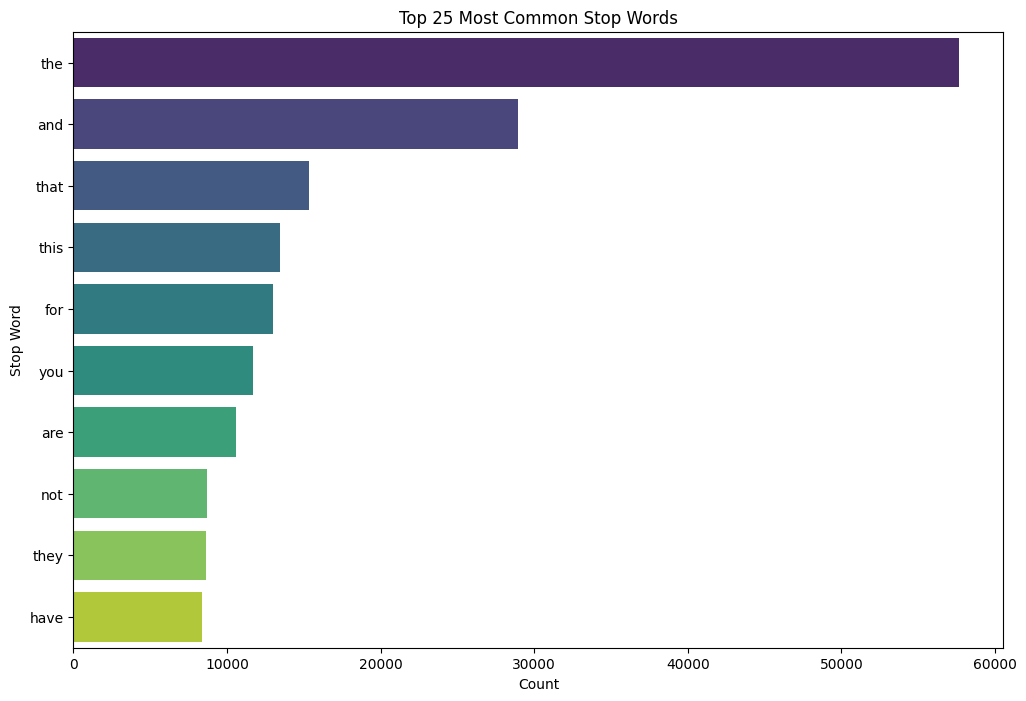

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(data = most_common_stop_word_df , x='frequency', y='stop_word', palette='viridis') # Create a bar plot of the most common stopwords
plt.title('Top 25 Most Common Stop Words') # Set the title of the plot
plt.xlabel('Count') # Set the x-axis label
plt.ylabel('Stop Word') # Set the y-axis label
plt.show() # Show the plot

In [ ]:
df['num_character'] = df['clean_comment'].apply(lambda x: len(x)) # Create a new column 'num_character' with the length of each comment

In [ ]:
df.head() # Display the first few rows including the new 'num_character' column

,clean_comment,category,word_count,num_stop_words,num_character
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [ ]:
df['num_character'].describe() # Display descriptive statistics for the 'num_character' column

,num_character
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


### 11. Punctuation Analysis

Counts punctuation characters in each comment. (Note: After earlier cleaning steps, this count might be zero as many non-alphanumeric characters were removed.)

In [ ]:
df['clean_comment'][0] # Display the first clean comment

'family mormon have never tried explain them they still stare puzzled from time time like some kind strange creature nonetheless they have come admire for the patience calmness equanimity acceptance and compassion have developed all the things buddhism teaches'

In [ ]:
from collections import Counter # Import Counter for counting hashable objects

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment']) # Join all clean comments into a single string

# Count the frequency of each character
char_frequency = Counter(all_text) # Count the frequency of each character in the combined text

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False) # Create a DataFrame from character frequencies

In [ ]:
char_frequency_df['character'].values # Display the characters from the character frequency DataFrame

array([' ', 'e', 't', ..., '段', '她', '谁'], dtype=object)

In [ ]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\\'()[]{}-']) # Count specified punctuation characters
)

df.sample(5) # Display a random sample of 5 rows including the new 'num_punctuation_chars' column

,clean_comment,category,word_count,num_stop_words,num_character,num_punctuation_chars
7799,jalsa paani jangiya,0,3,0,19,0
12393,bjp has good public image the local level know...,1,59,21,349,0
13700,vision country that plans completely eliminate...,0,31,9,202,0
34540,first time thats cute,1,4,0,21,0
24945,demonetisation and the growth bjp coffers are ...,0,9,4,61,0


### 12. N-gram Analysis

Identifies and visualizes the most frequent bigrams (two-word sequences) and trigrams (three-word sequences) to understand common phrases in the comments.

In [ ]:
df['num_punctuation_chars'].describe() # Display descriptive statistics for the 'num_punctuation_chars' column

,num_punctuation_chars
count,36793.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer # Import CountVectorizer for text feature extraction
import pandas as pd # Import pandas for data manipulation

def get_top_bigrams(text_data, top_n=25):
    # Create CountVectorizer for bigrams
    vectorizer = CountVectorizer(ngram_range=(2, 2))

    # Fit and transform the text data
    X = vectorizer.fit_transform(text_data)

    # Get bigram names
    bigrams = vectorizer.get_feature_names_out() # Get the feature names (bigrams)

    # Calculate total count of each bigram
    counts = X.sum(axis=0).A1

    # Create DataFrame
    bigram_df = pd.DataFrame({
        "Bigram": bigrams,
        "Count": counts
    })

    # Return top N bigrams
    return bigram_df.sort_values(by="Count", ascending=False).head(top_n)

In [ ]:
top_bigrams_df = get_top_bigrams(df['clean_comment'])
display(top_bigrams_df) # Get and display the top bigrams from 'clean_comment'

,Bigram,Count
445596,the same,2439
166407,for the,1779
31063,and the,1709
438328,that the,1406
453495,they are,1359
508897,with the,1197
19246,all the,984
171754,from the,929
517773,you are,904
196213,has been,896


/tmp/ipykernel_1255/2034851828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_bigrams_df, x='Count', y='Bigram', palette='viridis')


Text(0, 0.5, 'Bigram')

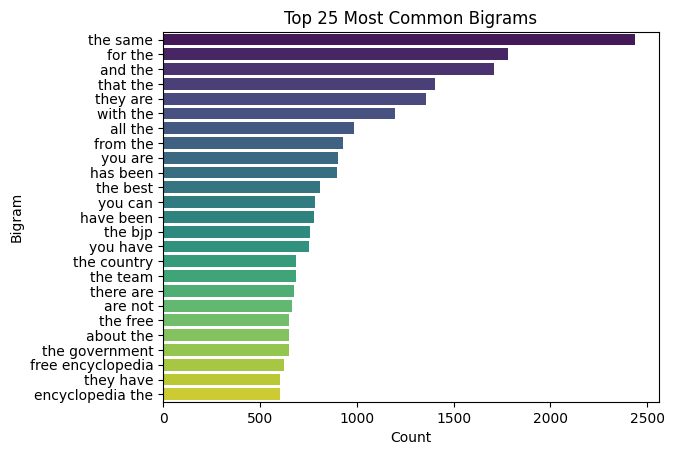

In [ ]:
sns.barplot(data = top_bigrams_df, x='Count', y='Bigram', palette='viridis') # Create a bar plot of the most common bigrams
plt.title('Top 25 Most Common Bigrams') # Set the title of the plot
plt.xlabel('Count') # Set the x-axis label
plt.ylabel('Bigram') # Set the y-axis label

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer # Import CountVectorizer for text feature extraction
import pandas as pd # Import pandas for data manipulation

def get_top_trigrams(text_data, top_n=25):
    # Create CountVectorizer for bigrams
    vectorizer = CountVectorizer(ngram_range=(3, 3)) # Initialize CountVectorizer to extract trigrams

    # Fit and transform the text data
    X = vectorizer.fit_transform(text_data) # Fit the vectorizer to the text data and transform it into a matrix of token counts

    # Get bigram names
    bigrams = vectorizer.get_feature_names_out() # Get the feature names (trigrams)

    # Calculate total count of each bigram
    counts = X.sum(axis=0).A1 # Sum the counts for each trigram across all documents

    # Create DataFrame
    trigram_df = pd.DataFrame({
        "Bigram": bigrams,
        "Count": counts
    }) # Create a DataFrame of trigrams and their counts

    # Return top N bigrams
    return trigram_df.sort_values(by="Count", ascending=False).head(top_n) # Sort by count and return the top N trigrams

In [ ]:
top_trigrams_df = get_top_trigrams(df['clean_comment'])
display(top_trigrams_df) # Get and display the top trigrams from 'clean_comment'

,Bigram,Count
701574,the free encyclopedia,623
271560,free encyclopedia the,604
226276,encyclopedia the team,598
421232,lot the same,399
692408,the best overall,375
722749,the team reached,322
719494,the same thing,317
294773,good good good,305
700365,the fact that,238
719302,the same lot,227


/tmp/ipykernel_1255/2204893711.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_trigrams_df, x='Count', y='Bigram', palette='viridis')


Text(0, 0.5, 'Bigram')

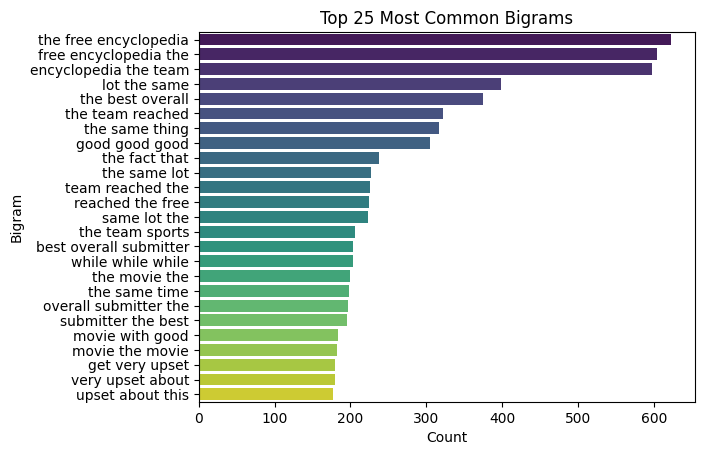

In [ ]:
sns.barplot(data = top_trigrams_df, x='Count', y='Bigram', palette='viridis') # Create a bar plot of the most common trigrams
plt.title('Top 25 Most Common Bigrams') # Set the title of the plot
plt.xlabel('Count') # Set the x-axis label
plt.ylabel('Bigram') # Set the y-axis label

### 13. Lemmatization

Applies lemmatization to the `clean_comment` column, reducing words to their base or root form (e.g., 'running' to 'run') to normalize word variations.

In [ ]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re # Import the regular expression module

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x))) # Remove non-English characters from comments

In [ ]:
all_text = ' '.join(df['clean_comment']) # Join all clean comments into a single string

# Count the frequency of each character
char_frequency = Counter(all_text) # Count the frequency of each character in the combined text

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False) # Create a DataFrame from character frequencies

char_frequency_df # Display the character frequency DataFrame

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [ ]:
from nltk.corpus import stopwords # Import stopwords from NLTK

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'} # Define English stopwords, excluding specific sentiment-relevant words

# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]) # Remove stopwords from comments
)

### 10. Character Count Analysis

Calculates the total number of characters in each comment and provides descriptive statistics.

In [ ]:
from nltk.stem import WordNetLemmatizer # Import WordNetLemmatizer for lemmatization

nltk.download('wordnet') # Download the WordNet corpus for lemmatization

# Define the lemmatizer
lemmatizer = WordNetLemmatizer() # Initialize the WordNet lemmatizer

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]) # Apply lemmatization to each word in comments
)

df.head() # Display the first few rows after lemmatization

[nltk_data] Downloading package wordnet to /root/nltk_data...


,clean_comment,category,word_count,num_stop_words,num_character,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


### 14. Word Cloud Visualization

Generates and displays word clouds for all comments, and separately for positive, neutral, and negative sentiment categories, to visually highlight frequently occurring words.

In [ ]:
from wordcloud import WordCloud # Import WordCloud for generating word clouds
import matplotlib.pyplot as plt # Import matplotlib for plotting

def create_wordcloud(text_data):

    # Combine all text into one string
    text = " ".join(text_data.dropna().astype(str)) # Combine all text data into a single string

    # Create WordCloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=None
    ).generate(text) # Generate a word cloud from the text

    # Display WordCloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show() # Display the word cloud

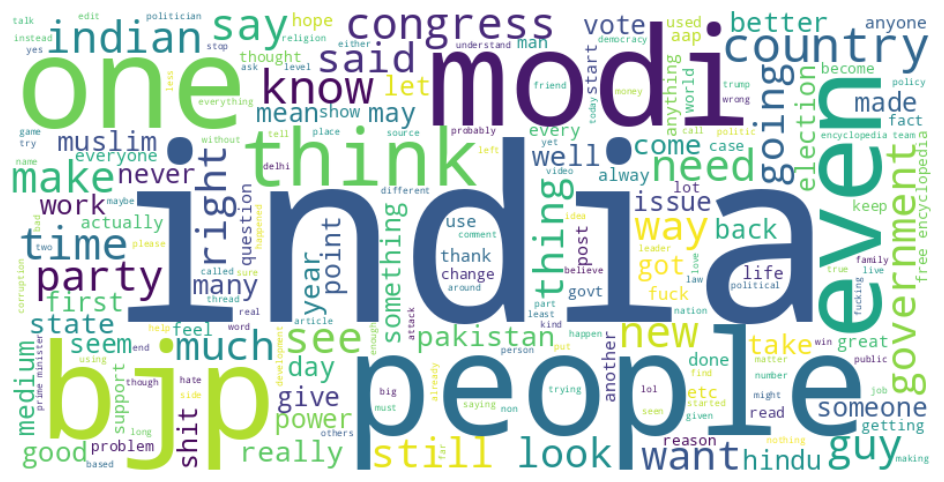

In [ ]:
create_wordcloud(df['clean_comment']) # Create a word cloud for all clean comments

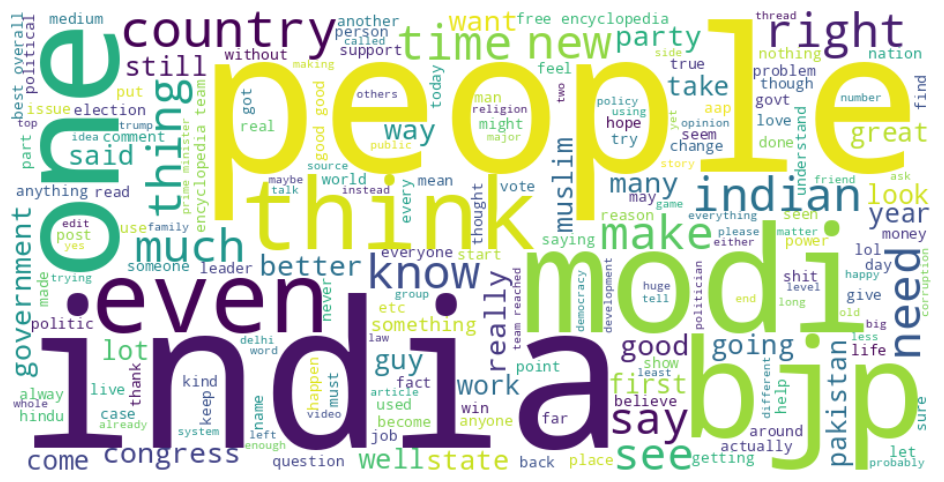

In [ ]:
create_wordcloud(df[df['category']==1]['clean_comment']) # Create a word cloud for comments in category 1 (positive sentiment)

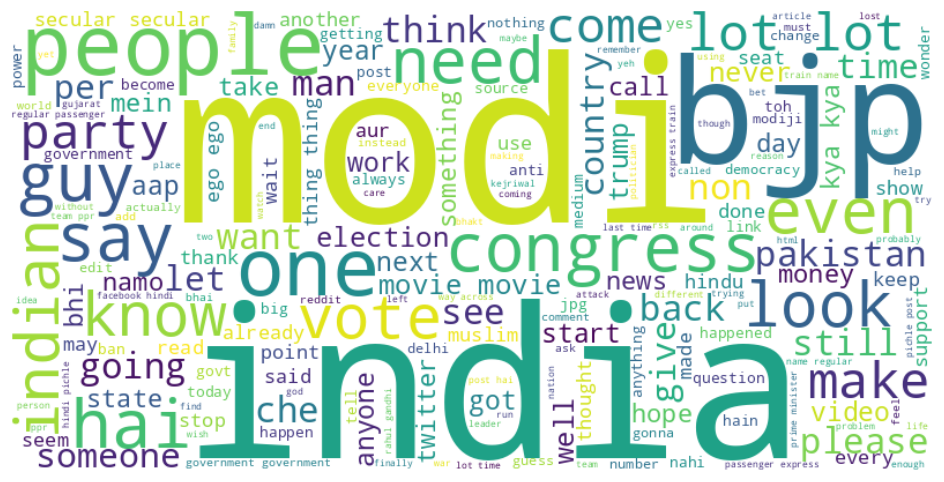

In [ ]:
create_wordcloud(df[df['category']==0]['clean_comment']) # Create a word cloud for comments in category 0 (neutral sentiment)

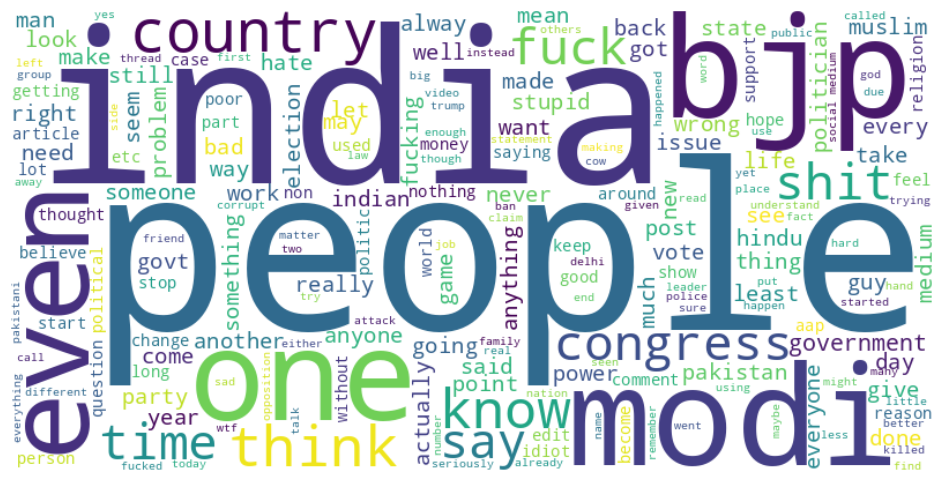

In [ ]:
create_wordcloud(df[df['category']==-1]['clean_comment']) # Create a word cloud for comments in category -1 (negative sentiment)

### 15. Top Words Analysis

Provides functions to plot the overall most frequent words and the most frequent words broken down by their sentiment category, offering insights into keywords associated with different sentiments.

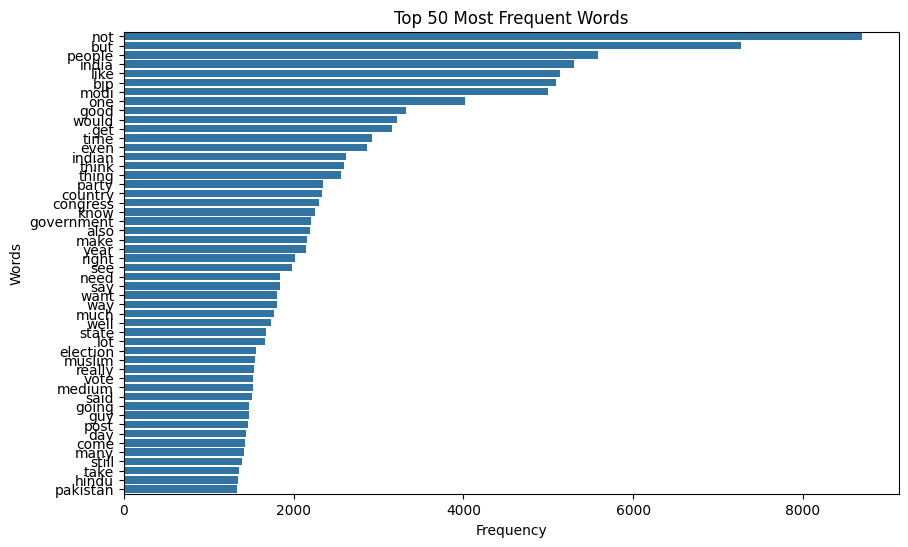

In [ ]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split() # Combine all clean comments into a single string and split into words

    # Get the top N most common words
    counter = Counter(words) # Count the frequency of each word
    most_common_words = counter.most_common(n) # Get the N most common words

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words) # Unzip words and their counts into separate lists

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words)) # Create a bar plot of the most common words
    plt.title(f'Top {n} Most Frequent Words') # Set the title of the plot
    plt.xlabel('Frequency') # Set the x-axis label
    plt.ylabel('Words') # Set the y-axis label
    plt.show() # Show the plot

# Example usage
plot_top_n_words(df, n=50) # Plot the top 50 most frequent words

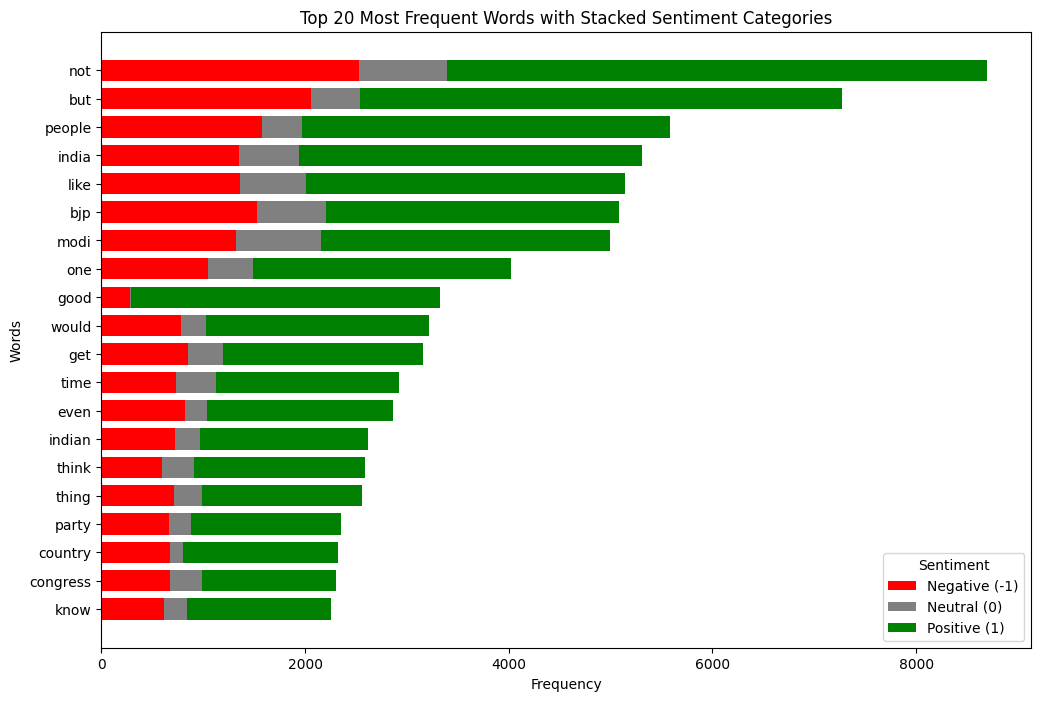

In [ ]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {} # Initialize a dictionary to store word counts by category

    for idx, row in df.iterrows():
        words = row['clean_comment'].split() # Split the clean comment into words
        category = row['category']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  # Initialize counts for each sentiment category if word is new

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1 # Increment the count for the specific word and category

    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()} # Calculate total counts for each word

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n] # Get the top N most common words based on total count
    top_words = [word for word, _ in most_common_words] # Extract just the words

    # Prepare data for plotting
    word_labels = top_words # Labels for the y-axis
    negative_counts = [word_category_counts[word][-1] for word in top_words] # Counts for negative sentiment
    neutral_counts = [word_category_counts[word][0] for word in top_words] # Counts for neutral sentiment
    positive_counts = [word_category_counts[word][1] for word in top_words] # Counts for positive sentiment

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8)) # Set the figure size
    bar_width = 0.75 # Set the width of the bars

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width) # Plot negative counts
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width) # Plot neutral counts stacked on negative
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width) # Plot positive counts stacked on negative and neutral

    plt.xlabel('Frequency') # Set the x-axis label
    plt.ylabel('Words') # Set the y-axis label
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories') # Set the title of the plot
    plt.legend(title='Sentiment', loc='lower right') # Display the legend
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show() # Show the plot



plot_top_n_words_by_category(df, n=20) # Plot the top 20 most frequent words by category

In [ ]:
# This cell is currently empty. You can add more code here if needed.